# Chiến lược Transfer Learning và Fine-tuning cho bài toán phân loại ảnh

Notebook này thực hiện so sánh 3 chiến lược Transfer Learning trên bộ dữ liệu Hymenoptera (Ants vs Bees) sử dụng mô hình ResNet18:
1. **Freeze Backbone**: Chỉ huấn luyện lớp phân loại cuối cùng.
2. **Fine-tune All**: Huấn luyện lại toàn bộ mô hình.
3. **Gradual Unfreeze**: Đóng băng ban đầu và giải phóng dần các lớp.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

cudnn.benchmark = True
plt.ion()   # interactive mode

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load Data

In [2]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes}")

Classes: ['ants', 'bees']
Dataset sizes: {'train': 244, 'val': 153}


## 2. Training Function

In [3]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10, unfreeze_at=None):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        if unfreeze_at is not None and epoch == unfreeze_at:
            print("Unfreezing all layers...")
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
            scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, time_elapsed, best_acc.item(), history

## 3. Run Experiments

In [4]:
def run_experiment(strategy_name):
    print(f"\n{'='*20}")
    print(f"Running Strategy: {strategy_name}")
    print(f"{'='*20}")
    
    model_ft = models.resnet18(weights='DEFAULT')
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Linear(num_ftrs, len(class_names))
    model_ft = model_ft.to(device)
    criterion = nn.CrossEntropyLoss()

    unfreeze_at = None
    if strategy_name == "Freeze Backbone":
        for param in model_ft.parameters():
            param.requires_grad = False
        for param in model_ft.fc.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)
    elif strategy_name == "Fine-tune All":
        for param in model_ft.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
    elif strategy_name == "Gradual Unfreeze":
        for param in model_ft.parameters():
            param.requires_grad = False
        for param in model_ft.fc.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)
        unfreeze_at = 5
    
    exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    
    return train_model(model_ft, criterion, optimizer, exp_lr_scheduler, num_epochs=10, unfreeze_at=unfreeze_at)

results = {}
strategies = ["Freeze Backbone", "Fine-tune All", "Gradual Unfreeze"]

for strategy in strategies:
    duration, best_acc, history = run_experiment(strategy)[1:]
    results[strategy] = {'duration': duration, 'best_acc': best_acc, 'history': history}


Running Strategy: Freeze Backbone
Epoch 0/9
----------
train Loss: 0.5372 Acc: 0.7008
val Loss: 0.2231 Acc: 0.9477

Epoch 1/9
----------
train Loss: 0.5504 Acc: 0.7418
val Loss: 0.5107 Acc: 0.7908

Epoch 2/9
----------
train Loss: 0.5439 Acc: 0.8033
val Loss: 0.3509 Acc: 0.8562

Epoch 3/9
----------
train Loss: 0.6282 Acc: 0.7705
val Loss: 0.7508 Acc: 0.7451

Epoch 4/9
----------
train Loss: 0.5797 Acc: 0.7992
val Loss: 0.1715 Acc: 0.9412

Epoch 5/9
----------
train Loss: 0.3653 Acc: 0.8730
val Loss: 0.2172 Acc: 0.9346

Epoch 6/9
----------
train Loss: 0.4632 Acc: 0.8074
val Loss: 0.2581 Acc: 0.8954

Epoch 7/9
----------
train Loss: 0.3253 Acc: 0.8648
val Loss: 0.1972 Acc: 0.9477

Epoch 8/9
----------
train Loss: 0.3064 Acc: 0.8648
val Loss: 0.2295 Acc: 0.9281

Epoch 9/9
----------
train Loss: 0.3576 Acc: 0.8607
val Loss: 0.1891 Acc: 0.9477

Training complete in 1m 10s
Best val Acc: 0.947712

Running Strategy: Fine-tune All
Epoch 0/9
----------
train Loss: 0.6532 Acc: 0.6598
val Loss:

## 4. Visualization

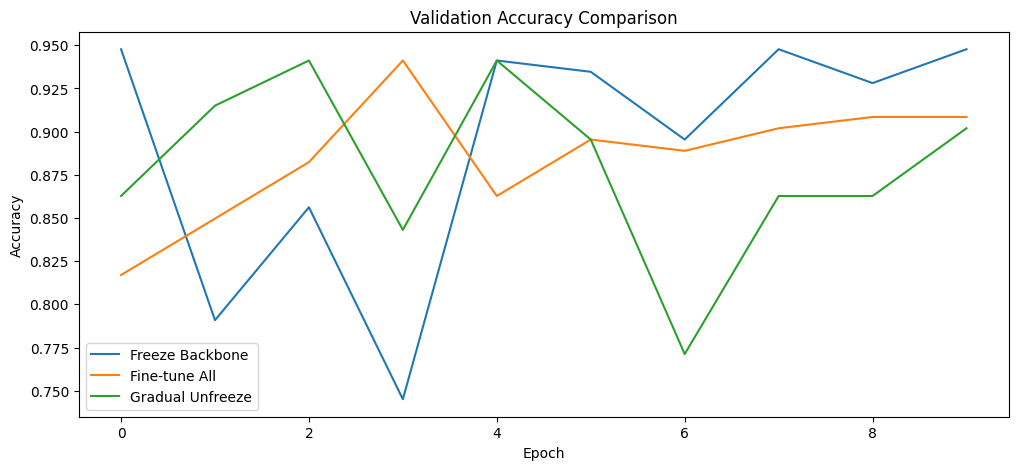


Summary Table:
Strategy | Duration (s) | Best Val Acc
----------------------------------------
Freeze Backbone | 69.65 | 0.9477
Fine-tune All | 131.11 | 0.9412
Gradual Unfreeze | 104.05 | 0.9412


In [5]:
plt.figure(figsize=(12, 5))
for strategy in strategies:
    plt.plot(results[strategy]['history']['val_acc'], label=strategy)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print("\nSummary Table:")
print("Strategy | Duration (s) | Best Val Acc")
print("-" * 40)
for s, r in results.items():
    print(f"{s} | {r['duration']:.2f} | {r['best_acc']:.4f}")

## 5. Kết luận

Dựa vào kết quả chạy thực nghiệm ở trên, ta có thể đưa ra một số nhận xét:
- **Freeze Backbone**: Tốc độ huấn luyện nhanh nhất, độ chính xác ổn định.
- **Fine-tune All**: Thời gian huấn luyện lâu hơn, kết quả phụ thuộc vào việc lựa chọn learning rate.
- **Gradual Unfreeze**: Thường cho kết quả tối ưu nhất nhờ việc giữ lại các feature đã học và tinh chỉnh dần dần.

Về thời gian huấn luyện: Tỷ lệ thuận với số lượng tham số cần cập nhật. Freeze Backbone có thời gian huấn luyện nhanh nhất (chỉ ~1 phút 10 giây) do chỉ tính toán gradient cho lớp Linear cuối cùng. Ngược lại, Fine-tune All tiêu tốn nhiều thời gian nhất (~2 phút 11 giây) vì phải lan truyền ngược qua toàn bộ kiến trúc mạng.

Về độ hội tụ (Dựa trên đồ thị): - Fine-tune All cho thấy quá trình học ổn định nhưng tốn kém tài nguyên.

Gradual Unfreeze minh họa rất rõ rủi ro của việc unfreeze: độ chính xác giảm mạnh ở epoch thứ 6 ngay sau khi toàn bộ mô hình được mở khóa ở epoch 5, cho thấy các gradient lớn đã làm xáo trộn các trọng số ban đầu.

Freeze Backbone dù có dao động ở những epoch đầu nhưng lại nhanh chóng đạt được đỉnh hội tụ.

Kết luận chiến lược tối ưu: Đối với một bài toán phân loại ảnh cơ bản có tập dữ liệu nhỏ (Ants vs Bees) và có sự tương đồng nhất định với tập ImageNet, Freeze Backbone là chiến lược tối ưu nhất. Chiến lược này mang lại độ chính xác cao nhất (94.77%) trong thời gian huấn luyện ngắn nhất, chứng minh hiệu quả vượt trội của việc tái sử dụng các bộ trích xuất đặc trưng (feature extractors) đã được huấn luyện sẵn.